In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("data/csv_output/full_dataset.csv")

In [3]:
print(df.columns.tolist())

['date', 'station_code', 'station_name', 'lat', 'lon', 'DANGER_RATING', 'elevation', 'EVI', 'NDVI', 'max_temp', 'mean_temp', 'max_wind_east', 'max_wind_north', 'mean_wind_east', 'mean_wind_north', 'precipitation_sum', 'mean_snow_depth', 'sum_snowfall', 'sum_snowmelt', 'rootzone_wetness_mean', 'rootzone_wetness_max', 'surface_temp_mean', 'surface_temp_max', 'surface_wetness_mean', 'surface_wetness_max', 'evapotranspiration_mean', 'evapotranspiration_max', 'max_solar_radiation', 'mean_dewpoint', 'mean_evaporation', 'mean_low_cloud_cover', 'mean_soil_water', 'mean_total_cloud_cover']


In [4]:
# Drop invalid data
# Reasons for dropping
# Weather stations 964 and 1239 are not inside BC
# EVI and NDVI had a problem on 2024-08-12 and majority of data is NULL
# Cropping data to fit with everything (>= "2015-04-01 & <= "2025-07-15)
df['date'] = pd.to_datetime(df['date'])
df = df[~df.station_code.isin(["964","1239"])]
df = df[(df.date != "2024-08-12") & 
        (df.date >= "2015-04-01") & 
        (df.date <= "2025-07-15")]

In [5]:
# Interpolate NDVI and EVI 16 day inbetween points
df = df.sort_values(['station_code','date'])
df[['EVI','NDVI']] = (
    df
    .groupby('station_code')[['EVI','NDVI']]
    .transform(lambda grp: 
         grp
         .interpolate(method='linear')
         .ffill()
         .bfill()
    )
)

# Standard ffill and bfill NO interpolation
"""
df[['EVI','NDVI']] = (
    df
    .groupby('station_code')[['EVI','NDVI']]
    .transform(lambda grp: grp.ffill().bfill())
)
"""

"\ndf[['EVI','NDVI']] = (\n    df\n    .groupby('station_code')[['EVI','NDVI']]\n    .transform(lambda grp: grp.ffill().bfill())\n)\n"

In [6]:
# Feature Engineering

# Average and max wind speed (remove components)
df["average_wind_speed"] = np.sqrt(df["mean_wind_east"]**2 + df["mean_wind_north"]**2)
df["max_wind_speed"] = np.sqrt(df["max_wind_east"]**2 + df["max_wind_north"]**2)
df.drop(["mean_wind_east","mean_wind_north", "max_wind_east", "max_wind_north"], axis=1, inplace=True)

# Calculate seasons
df["doy"] = df["date"].dt.dayofyear
df["sin_doy"] = np.sin(2 * np.pi * df["doy"] / 365)
df["cos_doy"] = np.cos(2 * np.pi * df["doy"] / 365)
df.drop(["doy"], axis=1, inplace=True)

In [7]:
# Aggregation

# 7/14 day percipitation sum and mean
df["precip_7day_sum"] = (
    df.groupby("station_code")["precipitation_sum"]
      .transform(lambda x: x.rolling(7, min_periods=1).sum())
)
df["precip_14day_sum"] = (
    df.groupby("station_code")["precipitation_sum"]
      .transform(lambda x: x.rolling(14, min_periods=1).sum())
)
df["precip_7day_mean"] = (
    df.groupby("station_code")["precipitation_sum"]
      .transform(lambda x: x.rolling(7, min_periods=1).mean())
)
df["precip_14day_mean"] = (
    df.groupby("station_code")["precipitation_sum"]
      .transform(lambda x: x.rolling(14, min_periods=1).mean())
)

# 7/14 day temperature sum and mean
df["temp_7day_sum"] = (
    df.groupby("station_code")["mean_temp"]
      .transform(lambda x: x.rolling(7, min_periods=1).sum())
)
df["temp_14day_sum"] = (
    df.groupby("station_code")["mean_temp"]
      .transform(lambda x: x.rolling(14, min_periods=1).sum())
)
df["temp_7day_mean"] = (
    df.groupby("station_code")["mean_temp"]
      .transform(lambda x: x.rolling(7, min_periods=1).mean())
)
df["temp_14day_mean"] = (
    df.groupby("station_code")["mean_temp"]
      .transform(lambda x: x.rolling(14, min_periods=1).mean())
)

In [8]:
# Drop unnecessary columns for training
df.drop(["date","station_name", "station_code"], axis=1, errors="ignore", inplace=True)
df = df.dropna()

In [9]:
print(df.columns.tolist())

['lat', 'lon', 'DANGER_RATING', 'elevation', 'EVI', 'NDVI', 'max_temp', 'mean_temp', 'precipitation_sum', 'mean_snow_depth', 'sum_snowfall', 'sum_snowmelt', 'rootzone_wetness_mean', 'rootzone_wetness_max', 'surface_temp_mean', 'surface_temp_max', 'surface_wetness_mean', 'surface_wetness_max', 'evapotranspiration_mean', 'evapotranspiration_max', 'max_solar_radiation', 'mean_dewpoint', 'mean_evaporation', 'mean_low_cloud_cover', 'mean_soil_water', 'mean_total_cloud_cover', 'average_wind_speed', 'max_wind_speed', 'sin_doy', 'cos_doy', 'precip_7day_sum', 'precip_14day_sum', 'precip_7day_mean', 'precip_14day_mean', 'temp_7day_sum', 'temp_14day_sum', 'temp_7day_mean', 'temp_14day_mean']


# Make sure you have run all previous modules before proceeding

### Model Evaluation (runs a bunch models and outputs their preformance)

In [ ]:
import os, random, time
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.base import ClassifierMixin
from sklearn.metrics import mean_squared_error, mean_absolute_error, cohen_kappa_score, accuracy_score
from sklearn.utils.class_weight import compute_sample_weight

# --- Reproducibility ---
random.seed(42); np.random.seed(42); os.environ["PYTHONHASHSEED"]="42"

# --- Prepare data ---
y = df["DANGER_RATING"].astype(int)
X = df.drop(columns="DANGER_RATING")

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ========== BASELINE ==========
dummy = DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr)
print("\n--- Dummy Classifier ---")
print(f"Validation Accuracy: {accuracy_score(y_val, dummy.predict(X_val)):.2%}")

# --- Models: sklearn-only ---
models = {
    "LR": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42),

    "RF-Classifier": RandomForestClassifier(
        n_estimators=100, class_weight=None, n_jobs=-1, random_state=42
    ),
    # sklearn-only “balanced” approximation
    "Balanced RF (sklearn)": RandomForestClassifier(
        n_estimators=300, class_weight="balanced_subsample", n_jobs=-1, random_state=42
    ),
}

labels = np.unique(y)

for name, model in models.items():
    print(f"\n--- {name} ---")

    steps = []
    if name in ("LR", "Ridge"):
        steps.append(("scaler", StandardScaler()))
    steps.append(("model", model))
    pipe = Pipeline(steps)

    fit_kwargs = {}
    if isinstance(model, ClassifierMixin) and "RF" in name:
        sw = compute_sample_weight(class_weight="balanced", y=y_tr)
        fit_kwargs = {"model__sample_weight": sw}

    t0 = time.time()
    best = pipe.fit(X_tr, y_tr, **fit_kwargs)
    print(f"Training took {time.time()-t0:.1f}s")

    if isinstance(model, ClassifierMixin):
        y_pred = best.predict(X_val)
        acc   = accuracy_score(y_val, y_pred)
        kappa = cohen_kappa_score(y_val, y_pred, weights="quadratic")
        within_one = np.mean(np.abs(y_val - y_pred) <= 1)
        print(f"Exact Accuracy           : {acc:.2%}")
        print(f"Within ±1 accuracy       : {within_one:.2%}")
        print(f"Quadratic Weighted Kappa : {kappa:.4f}")
        print("\n--- Accuracy by Class ---")
        for cls in labels:
            mask = (y_val == cls)
            total = mask.sum()
            acc_cls = (y_pred[mask] == cls).sum() / total if total else np.nan
            print(f"  Class {cls}: {acc_cls:.2%}")
    else:
        y_hat = best.predict(X_val)
        mse  = mean_squared_error(y_val, y_hat)
        rmse = np.sqrt(mse)
        mae  = mean_absolute_error(y_val, y_hat)
        print(f"Validation MSE           : {mse:.4f}")
        print(f"Validation RMSE          : {rmse:.4f}")
        print(f"Validation MAE           : {mae:.4f}")

        y_round = np.clip(np.rint(y_hat), labels.min(), labels.max()).astype(int)
        mae_r  = mean_absolute_error(y_val, y_round)
        rmse_r = np.sqrt(mean_squared_error(y_val, y_round))
        within_one = np.mean(np.abs(y_val - y_round) <= 1)
        kappa = cohen_kappa_score(y_val, y_round, weights="quadratic")
        acc   = accuracy_score(y_val, y_round)
        print(f"Rounded MAE              : {mae_r:.4f}")
        print(f"Rounded RMSE             : {rmse_r:.4f}")
        print(f"Exact Accuracy (rounded) : {acc:.2%}")
        print(f"Within ±1 accuracy       : {within_one:.2%}")
        print(f"Quadratic Weighted Kappa : {kappa:.4f}")
        print("\n--- Accuracy by Class (rounded) ---")
        for cls in labels:
            mask = (y_val == cls)
            total = mask.sum()
            acc_cls = (y_round[mask] == cls).sum() / total if total else np.nan
            print(f"  Class {cls}: {acc_cls:.2%}")



--- Dummy Classifier ---
Validation Accuracy: 33.49%

--- LR ---
Training took 1.0s
Validation MSE           : 0.5312
Validation RMSE          : 0.7288
Validation MAE           : 0.5757
Rounded MAE              : 0.5032
Rounded RMSE             : 0.7657
Exact Accuracy (rounded) : 53.75%
Within ±1 accuracy       : 96.02%
Quadratic Weighted Kappa : 0.7574

--- Accuracy by Class (rounded) ---
  Class 1: 57.50%
  Class 2: 60.93%
  Class 3: 59.93%
  Class 4: 36.27%
  Class 5: 15.68%

--- Ridge ---
Training took 0.6s
Validation MSE           : 0.5312
Validation RMSE          : 0.7288
Validation MAE           : 0.5757
Rounded MAE              : 0.5031
Rounded RMSE             : 0.7657
Exact Accuracy (rounded) : 53.76%
Within ±1 accuracy       : 96.01%
Quadratic Weighted Kappa : 0.7574

--- Accuracy by Class (rounded) ---
  Class 1: 57.52%
  Class 2: 60.94%
  Class 3: 59.95%
  Class 4: 36.26%
  Class 5: 15.68%

--- Random Forest ---


### Since Balanced Random Forest Classifier preformed the best, train it on the full dataset and save the model as a .pkl file

In [10]:
import os
import random
import joblib
import pickle
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight

# --- Reproducibility ---
random.seed(42)
np.random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

# --- Load your dataset ---
# df = pd.read_csv("your_dataset.csv")  # Uncomment and load your data
y = df["DANGER_RATING"].astype(int)
X = df.drop(columns="DANGER_RATING")

# --- Balanced RF (sklearn) ---
brf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced_subsample",  # rebalance per tree
    n_jobs=-1,
    random_state=42
)

# sample weights for extra balancing
sample_w = compute_sample_weight(class_weight="balanced", y=y)

# --- Train on FULL dataset ---
print("Training Balanced RF on full dataset...")
brf.fit(X, y, sample_weight=sample_w)

# --- Save exactly what your loader expects ---
# Your loader calls: joblib.load("rf_model.pkl")
joblib.dump(brf, "rf_model.pkl")
print("Model saved to rf_model.pkl")

Training Balanced RF on full dataset...
Model saved to rf_model.pkl
Also saved balanced_rf_model.joblib and balanced_rf_model.pkl


### Get feature importance for balanced random forest model

Most important feature: precip_14day_sum (0.057)
Least important feature: mean_soil_water (0.000)

Feature ranking:
precip_14day_sum           0.057022
precip_14day_mean          0.056075
surface_temp_mean          0.040725
surface_temp_max           0.037808
elevation                  0.037122
lat                        0.037002
precip_7day_mean           0.034914
precip_7day_sum            0.034338
temp_7day_sum              0.032372
cos_doy                    0.031915
temp_14day_sum             0.031901
temp_14day_mean            0.031870
surface_wetness_max        0.031359
mean_temp                  0.030959
temp_7day_mean             0.030881
lon                        0.030826
surface_wetness_mean       0.030139
NDVI                       0.026857
sin_doy                    0.026549
EVI                        0.026537
max_solar_radiation        0.025691
mean_evaporation           0.024974
rootzone_wetness_max       0.024078
rootzone_wetness_mean      0.024071
max_wind_speed      

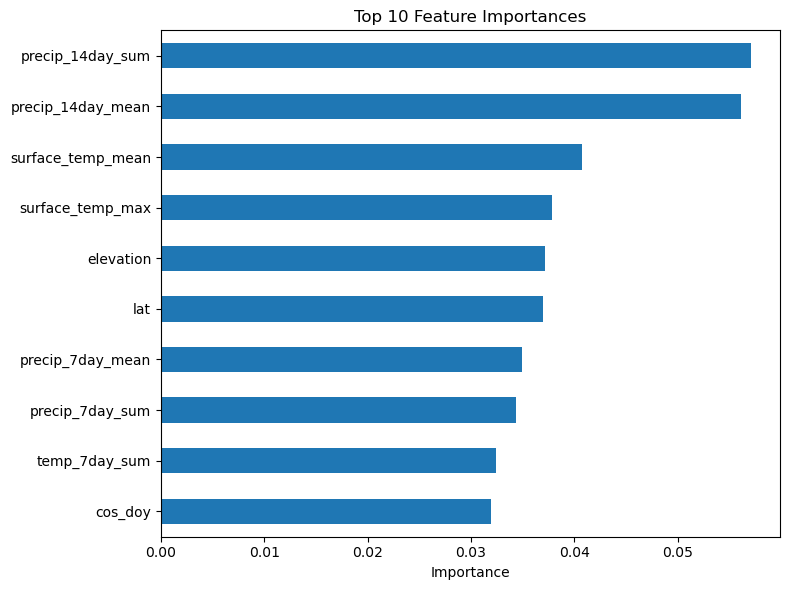

In [10]:
import matplotlib.pyplot as plt
import joblib
import pandas as pd

# Path to your saved model
MODEL_PATH = "rf_model.pkl"

# Load the model with joblib
brf = joblib.load(MODEL_PATH)

# Get feature importances
feat_names = list(brf.feature_names_in_)  # stored during training
importances = brf.feature_importances_

# Create a Series for ranking
feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)

# Print results
print("Most important feature:", feat_imp.idxmax(), f"({feat_imp.max():.3f})")
print("Least important feature:", feat_imp.idxmin(), f"({feat_imp.min():.3f})")

print("\nFeature ranking:")
print(feat_imp)
plt.figure(figsize=(8, 6))
feat_imp.head(10).plot(kind="barh")
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


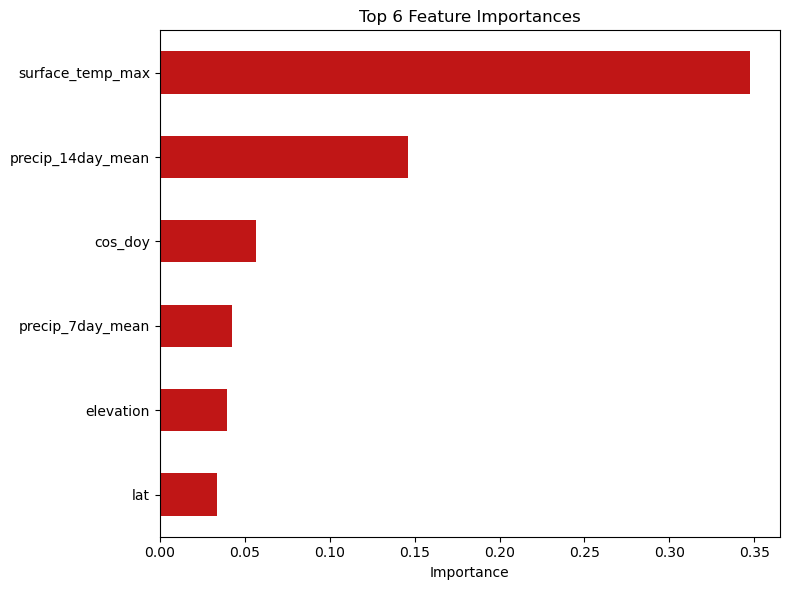

In [13]:
# --- Plot Top 10 ---
plt.figure(figsize=(8, 6))
feat_imp.head(6).plot(kind="barh", color="#c01616")  # Use your hex code
plt.xlabel("Importance")
plt.title("Top 6 Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()

# Save with transparent background
plt.savefig("feature_importance.png", transparent=True, dpi=300)

# Or just show (not transparent in most cases)
plt.show()
